# 使用完全連接層估算簡單線性迴歸的參數w、b

In [1]:
# 載入套件
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from sklearn.linear_model import LinearRegression

## 產生隨機資料

In [2]:
# 產生線性隨機資料100筆，介於 0-50
n = 100
X = np.linspace(0, 50, n)
y = np.linspace(0, 50, n)

# 資料加一點雜訊(noise)
X += np.random.uniform(-10, 10, n)
y += np.random.uniform(-10, 10, n)

## 定義模型

In [3]:
# 定義模型
def create_model(input_feature: int, output_feature: int):
    model = nn.Sequential(
        nn.Linear(input_feature, output_feature),
        nn.Flatten(0, -1), # 所有維度轉成一維 
    )
    return model

## 定義訓練函數

In [4]:
def train(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 100,
    lr: float = 1e-4,
) -> tuple[list[float], list[float], list[float]]:
    model = create_model(1, 1)

    # 定義損失函數
    loss_fn = nn.MSELoss(reduction='sum')

    # 定義優化器
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_list: list[float] = []
    w_list: list[float] = []
    b_list: list[float] = []
    for epoch in range(epochs):  # 執行訓練週期
        y_pred: torch.Tensor = model(X)  # 預測值

        # 計算損失函數值
        # print(y_pred.shape, y.shape)
        MSE = loss_fn.forward(y_pred, y)

        # 梯度重置：改由優化器(Optimizer)控制
        optimizer.zero_grad()

        # 反向傳導
        MSE.backward()

        # 權重更新：改用 model.parameters 取代 w、b 逐一更新
        optimizer.step()

        # 記錄訓練結果
        linear_layer = cast(nn.Linear, model[0])
        if (epoch + 1) % 1000 == 0 or epochs < 1000:
            w_list.append(linear_layer.weight[:, 0].item())  # w.item()：轉成常數
            b_list.append(linear_layer.bias.item())
            loss_list.append(MSE.item())

    return w_list, b_list, loss_list

## 執行訓練

In [5]:
# 使用不同學習率及更多的執行週期訓練
X2, y2 = torch.FloatTensor(X.reshape(X.shape[0], 1)), torch.FloatTensor(y)
w_list, b_list, loss_list = train(X2, y2, epochs=10**5, lr=1e-5)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.922849714756012, b=0.9828569293022156


In [6]:
# 執行訓練
coef = np.polyfit(X, y, deg=1)

# 取得 w、b 的最佳解
print(f'w={coef[0]}, b={coef[1]}')

w=0.9222980978798706, b=2.8576723215593125


In [7]:
X2 = X.reshape(X.shape[0], 1)

lr = LinearRegression()
lr.fit(X2, y)

lr.coef_[0], lr.intercept_

(np.float64(0.9222980978798712), np.float64(2.8576723215593063))

## 顯示迴歸線

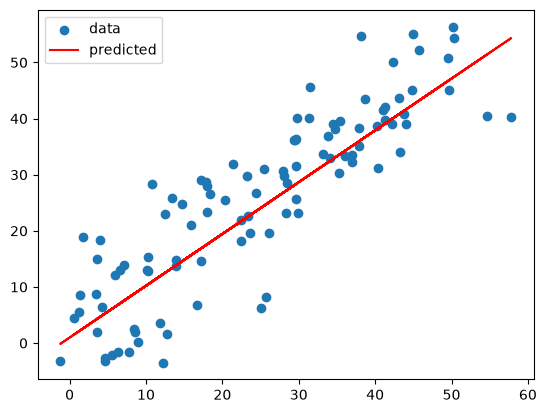

In [8]:
plt.scatter(X, y, label='data')
plt.plot(X, w_list[-1] * X + b_list[-1], 'r-', label='predicted')
plt.legend()

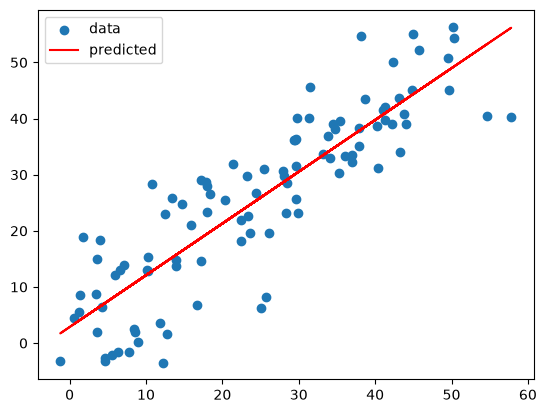

In [9]:
# NumPy 求得的迴歸線
plt.scatter(X, y, label='data')
plt.plot(X, coef[0] * X + coef[1], 'r-', label='predicted')
plt.legend()

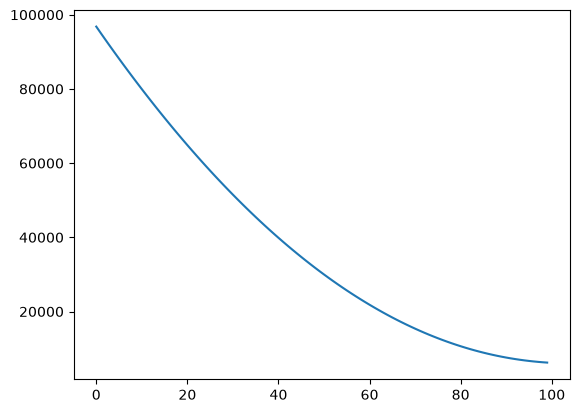

In [10]:
# 損失函數繪圖
plt.plot(loss_list)

In [11]:
loss_list

[96807.1796875,
 95037.28125,
 93288.4609375,
 91559.109375,
 89848.1953125,
 88155.21875,
 86479.890625,
 84822.0390625,
 83181.6171875,
 81558.875,
 79953.3828125,
 78365.125,
 76794.09375,
 75240.859375,
 73705.4140625,
 72187.1875,
 70686.15625,
 69202.8359375,
 67737.3203125,
 66289.03125,
 64857.92578125,
 63443.99609375,
 62047.2578125,
 60667.6953125,
 59305.359375,
 57960.23046875,
 56632.58984375,
 55323.7265625,
 54031.9921875,
 52757.390625,
 51499.921875,
 50259.5859375,
 49036.3828125,
 47830.3046875,
 46641.3671875,
 45469.5546875,
 44314.87890625,
 43177.33203125,
 42058.66015625,
 40958.55859375,
 39875.53125,
 38809.58984375,
 37760.6796875,
 36728.796875,
 35713.9375,
 34716.11328125,
 33735.31640625,
 32771.546875,
 31824.8046875,
 30896.25390625,
 29986.20703125,
 29093.08984375,
 28216.8984375,
 27357.634765625,
 26515.30078125,
 25690.8359375,
 24884.84375,
 24095.67578125,
 23323.33203125,
 22567.806640625,
 21829.109375,
 21107.232421875,
 20402.177734375,
 197

In [12]:
w_list

[-0.03877914696931839,
 -0.028833646327257156,
 -0.018909119069576263,
 -0.008996766060590744,
 0.0009088176302611828,
 0.010810622945427895,
 0.020710058510303497,
 0.030608128756284714,
 0.04050508886575699,
 0.05039945989847183,
 0.060293830931186676,
 0.07018820196390152,
 0.08008257299661636,
 0.08997330814599991,
 0.09986022859811783,
 0.10974714905023575,
 0.11963406950235367,
 0.1295175850391388,
 0.1393970549106598,
 0.1492765247821808,
 0.15915599465370178,
 0.16903546452522278,
 0.17891493439674377,
 0.18879440426826477,
 0.19867387413978577,
 0.20855334401130676,
 0.21843039989471436,
 0.2282949686050415,
 0.23815953731536865,
 0.2480241060256958,
 0.25788867473602295,
 0.2677532434463501,
 0.27761781215667725,
 0.2874823808670044,
 0.29734694957733154,
 0.3072115182876587,
 0.31707608699798584,
 0.326940655708313,
 0.3367892801761627,
 0.3466240465641022,
 0.3564588129520416,
 0.3662935793399811,
 0.37612834572792053,
 0.38596311211586,
 0.39579787850379944,
 0.40563264489

In [13]:
b_list

[0.018554117530584335,
 0.028500676155090332,
 0.03842664137482643,
 0.04834052920341492,
 0.058247826993465424,
 0.06815125048160553,
 0.0780530720949173,
 0.08795489370822906,
 0.09785594046115875,
 0.1077503114938736,
 0.11764468252658844,
 0.12753905355930328,
 0.13743342459201813,
 0.14732779562473297,
 0.15722216665744781,
 0.16711653769016266,
 0.1770109087228775,
 0.18690527975559235,
 0.19679266214370728,
 0.20667213201522827,
 0.21655160188674927,
 0.22643107175827026,
 0.23631054162979126,
 0.24619001150131226,
 0.25606033205986023,
 0.2659249007701874,
 0.2757894694805145,
 0.2856540381908417,
 0.2955186069011688,
 0.30538317561149597,
 0.3152477443218231,
 0.32511231303215027,
 0.3349768817424774,
 0.34484145045280457,
 0.3547060191631317,
 0.36457058787345886,
 0.374435156583786,
 0.38429972529411316,
 0.3941642940044403,
 0.40402886271476746,
 0.41388076543807983,
 0.4237155318260193,
 0.43355029821395874,
 0.4433850646018982,
 0.45321983098983765,
 0.4630545973777771,
 